In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from copy import deepcopy
from rashomon import hasse, extract_pools, loss, aggregate, AIS, MCMC
M = 3
R = np.array([4, 3, 3])

num_profiles = 2**M
profiles, profile_map = hasse.enumerate_profiles(M)

all_policies = hasse.enumerate_policies(M, R)
num_policies = len(all_policies)

# Profile (0, 0, 0)
sigma_000 = None
mu_000 = np.array([0])
var_000 = np.array([1])

# Profile (0, 0, 1)
sigma_001 = np.array([[1]])
mu_001 = np.array([-2])
var_001 = np.array([1])

# Profile (0, 1, 0)
sigma_010 = np.array([[1]])
mu_010 = np.array([-3])
var_010 = np.array([1])

# Profile (0, 1, 1)
sigma_011 = np.array([[1], [0]])
mu_011 = np.array([-1, 2])
var_011 = np.array([1, 1])

# Profile (1, 0, 0)
sigma_100 = np.array([[0, 1]])
mu_100 = np.array([3, 4])
var_100 = np.array([1, 1])

# Profile (1, 0, 1)
sigma_101 = np.array([[0, 1], [0, np.inf]])
mu_101 = np.array([-5, 2.5, 1.5, -2.5])
var_101 = np.array([1, 1, 1, 1])

# Profile (1, 1, 0)
sigma_110 = np.array([[0, 1], [1, np.inf]])
mu_110 = np.array([0, -2.5])
var_110 = np.array([1, 1])

# Profile (1, 1, 1)
sigma_111 = np.array([[0, 1], [1, np.inf], [0, np.inf]])
mu_111 = np.array([3.5, -0.5, -1.5, -3.5])
var_111 = np.array([1, 1, 1, 1])

sigma = [sigma_000, sigma_001, sigma_010, sigma_011,
            sigma_100, sigma_101, sigma_110, sigma_111]

mu = [mu_000, mu_001, mu_010, mu_011,
        mu_100, mu_101, mu_110, mu_111]

var = [var_000, var_001, var_010, var_011,
        var_100, var_101, var_110, var_111]


In [39]:
policies_profiles = {}
policies_profiles_masked = {}
policies_ids_profiles = {}
pi_policies = {}
pi_pools = {}
for k, profile in enumerate(profiles):

    policies_temp = [(i, x) for i, x in enumerate(all_policies) if hasse.policy_to_profile(x) == profile]
    unzipped_temp = list(zip(*policies_temp))
    policies_ids_k = list(unzipped_temp[0])
    policies_k = list(unzipped_temp[1])
    policies_profiles[k] = deepcopy(policies_k)
    policies_ids_profiles[k] = policies_ids_k

    profile_mask = list(map(bool, profile))

    # Mask the empty arms
    for idx, pol in enumerate(policies_k):
        policies_k[idx] = tuple([pol[i] for i in range(M) if profile_mask[i]])
    policies_profiles_masked[k] = policies_k

    if np.sum(profile) > 0:
        pi_pools_k, pi_policies_k = extract_pools.extract_pools(policies_k, sigma[k])
        if len(pi_pools_k.keys()) != mu[k].shape[0]:
            print(f"Profile {k}. Expected {len(pi_pools_k.keys())} pools. Received {mu[k].shape[0]} means.")
        pi_policies[k] = pi_policies_k
        # pi_pools_k has indicies that match with policies_profiles[k]
        # Need to map those indices back to all_policies
        pi_pools[k] = {}
        for x, y in pi_pools_k.items():
            y_full = [policies_profiles[k][i] for i in y]
            y_agg = [all_policies.index(i) for i in y_full]
            pi_pools[k][x] = y_agg
    else:
        pi_policies[k] = {0: 0}
        pi_pools[k] = {0: [0]}

In [40]:
def generate_data(mu, var, n_per_pol, all_policies, pi_policies, M):
    num_data = num_policies * n_per_pol
    X = np.zeros(shape=(num_data, M))
    D = np.zeros(shape=(num_data, 1), dtype='int_')
    y = np.zeros(shape=(num_data, 1))

    idx_ctr = 0
    for k, profile in enumerate(profiles):
        policies_k = policies_profiles[k]

        for idx, policy in enumerate(policies_k):
            policy_idx = [i for i, x in enumerate(all_policies) if x == policy]

            pool_id = pi_policies[k][idx]
            mu_i = mu[k][pool_id]
            var_i = var[k][pool_id]
            y_i = np.random.normal(mu_i, var_i, size=(n_per_pol, 1))

            start_idx = idx_ctr * n_per_pol
            end_idx = (idx_ctr + 1) * n_per_pol

            X[start_idx:end_idx, ] = policy
            D[start_idx:end_idx, ] = policy_idx[0]
            y[start_idx:end_idx, ] = y_i

            idx_ctr += 1

    return X, D, y

In [41]:
num_samples_per_feature = 500

np.random.seed(721)
X, D, y = generate_data(mu, var, num_samples_per_feature, all_policies, pi_policies, M)
policy_means = loss.compute_policy_means(D, y, num_policies)

In [42]:
H = np.inf
theta = 13.3
lamb = 1
R_set, R_profiles = aggregate.RAggregate(M, R, H, D, y, theta, reg=lamb, verbose=True, bruteforce=False)

(0, 0, 0) 12.330368826815754
Profile (0, 0, 0) has 1 objects in Rashomon set
(0, 0, 1) 12.358771154581058
Adaptive
Profile (0, 0, 1) took 0.00687408447265625 s adaptively
Profile (0, 0, 1) has 2 objects in Rashomon set
(0, 1, 0) 12.358733805947402
Adaptive
Profile (0, 1, 0) took 0.004016876220703125 s adaptively
Profile (0, 1, 0) has 2 objects in Rashomon set
(0, 1, 1) 12.410226432167857
Adaptive
Profile (0, 1, 1) took 0.02795577049255371 s adaptively
Profile (0, 1, 1) has 4 objects in Rashomon set
(1, 0, 0) 12.389727673487013
Adaptive
Profile (1, 0, 0) took 0.024113893508911133 s adaptively
Profile (1, 0, 0) has 4 objects in Rashomon set
(1, 0, 1) 12.473944971588377
Adaptive
Profile (1, 0, 1) took 0.02970600128173828 s adaptively
Profile (1, 0, 1) has 8 objects in Rashomon set
(1, 1, 0) 12.472513798995353
Adaptive
Profile (1, 1, 0) took 0.01316690444946289 s adaptively
Profile (1, 1, 0) has 8 objects in Rashomon set
(1, 1, 1) 12.629301267001312
Adaptive
Profile (1, 1, 1) took 0.059777

In [43]:
anchors = AIS.build_anchor_states(R_set, R_profiles, M, R)
prof_idx_of_policy, profiles = AIS.build_profile_index_of_policy(all_policies, hasse.policy_to_profile)

RPS_states = AIS.raggregate_to_states((R_set, R_profiles), profiles)
score_s = AIS.make_score_s_expneg_raw(
    D=D,
    y=y,
    M=M,
    R=R,
    prof_idx_of_policy = prof_idx_of_policy,
    policies=all_policies,
    policy_means=policy_means,
    reg=lamb,
    lattice_edges=None,   # or your edges
    beta=1.0,             # exp(-loss)
    prior_logprob=lambda state: 0.0
)

In [ ]:
import math
log_alpha = [math.log(max(1e-300, score_s(A))) for A in anchors]

buckets = AIS.make_p0_buckets_weighted_S0(RPS_states, np.asarray(R,int), log_alpha,
                                      eps1=0.05, eps2=0.25, min_len=1)
log_p0 = lambda z: AIS.log_p0_distance_weighted_S0(z, buckets)

# 3) Run pilot
ladder, ess_ratios = AIS.pilot_adaptive_ladder(
    init_sampler=lambda N: MCMC.init_from_RPS_batch(RPS_states, log_alpha, N, rng_seed=777),
    log_p0=log_p0,
    score_s=score_s,
    N=512,
    ess_target=0.80,
    beta0=0.0, beta1=1.0,
    initial_delta=0.05,
    min_delta=1e-3,
    moves_per_probe=3,   # small mixing at each accepted β (optional)
    min_len=1,
    rng_seed=777
)
print("Adaptive ladder has", len(ladder), "levels; first 10:", ladder[:10])
print("Per-step ESS ratios (len =", len(ess_ratios), "):", ess_ratios[:10])

KeyboardInterrupt: 

In [ ]:
cfg = AIS.AISConfig(n_paths=300, n_levels=20, moves_per_level=5, min_len=1, seed=2)
out_5test = AIS.run_ais_state_streaming(
    anchors=R_set,          # not used by q0, but you may keep for consistency
    score_s=score_s,        # returns exp(-loss(state)) or similar
    cfg=cfg,
    RPS=RPS_states,              # your Rashomon partitions as a list of State
    R_per=R,  # levels per arm (includes control)
    eps1=0.5, eps2=0.75,
    out_jsonl = "AIS_samples_test.jsonl",
    ladder=ladder
)

In [33]:
ais_samples = AIS.load_ais_from_jsonl("AIS_samples_test.jsonl")

In [34]:
summ = AIS.ais_quantiles_for_all_policies(
    ais_samples,
    D, y,                     # D[:,0] = global policy id; y is (N,) or (N,1)
    M,
    all_policies,                 # global policies list (len P)
    prof_idx_of_policy,       # length-P array: global policy id -> profile k
    R,                    # per-arm levels (len M)
    lattice_edges=None,
    mu0=0.0, kappa0=1.0, alpha0=2.0, beta0=2.0,
    p=[0.025,0.5,0.975], # make this a vector
    seed=None
)

In [44]:
n_policies = len(all_policies)
true_mu = np.empty(n_policies, dtype=float)
true_var = np.empty(n_policies, dtype=float)
for k, profile in enumerate(profiles):
    policies_k = policies_profiles[k]

    for idx, policy in enumerate(policies_k):
        policy_idx = [i for i, x in enumerate(all_policies) if x == policy]

        pool_id = pi_policies[k][idx]
        mu_i = mu[k][pool_id]
        var_i = var[k][pool_id]
        true_mu[policy_idx[0]] = mu_i
        true_var[policy_idx[0]] = var_i

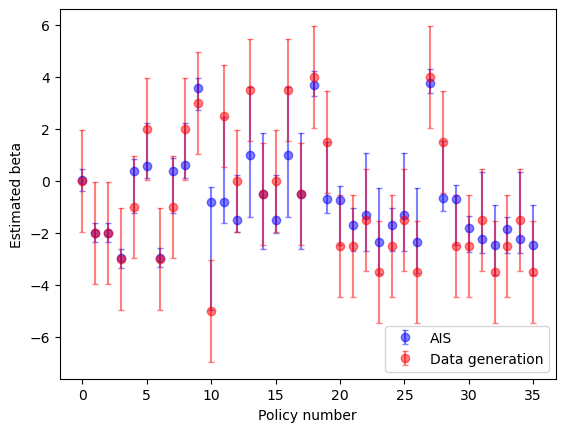

In [ ]:
plt.figure()
plt.errorbar(range(36), summ["0.5"], yerr=[summ["0.5"]-summ["0.025"], summ["0.975"]-summ["0.5"]], fmt='o', capsize=2, color = 'blue', alpha = 0.5, label = 'AIS')
plt.errorbar(range(36), true_mu, yerr=[1.96*np.sqrt(true_var), 1.96*np.sqrt(true_var)], fmt='o', capsize=2, color = 'red', alpha = 0.5, label = 'Data generation')
plt.xlabel("Policy number")
plt.ylabel("Estimated beta")

plt.legend()

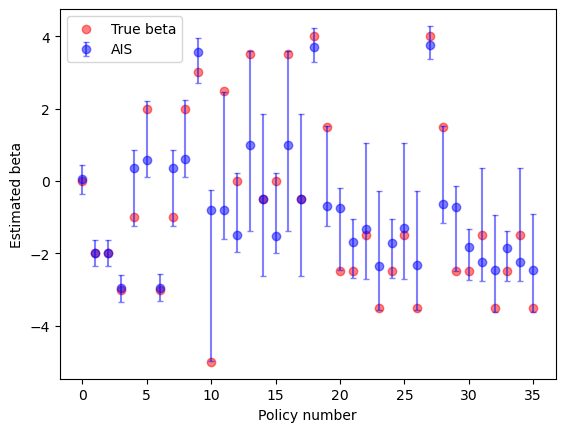

In [37]:
plt.figure()
plt.errorbar(range(36), summ["0.5"], yerr=[summ["0.5"]-summ["0.025"], summ["0.975"]-summ["0.5"]], fmt='o', capsize=2, color = 'blue', alpha = 0.5, label = 'AIS')
plt.scatter(range(36), true_mu, color = 'red', alpha = 0.5, label = 'True beta')
plt.xlabel("Policy number")
plt.ylabel("Estimated beta")

plt.legend()

In [ ]:
def extract_policy_posteriors_from_MCMC_RPS_sample(
    states,
    logw,
    D, y,                     # D[:,0] = global policy id; y is (N,) or (N,1)
    M,
    policies,                 # global policies list (len P)
    prof_idx_of_policy,       # length-P array: global policy id -> profile k
    R,                    # per-arm levels (len M)
    lattice_edges=None,
    mu0=0.0, kappa0=1.0, alpha0=2.0, beta0=2.0,
    seed=None):
    """
    Parameters
    ----------
    ais_sample : list of dicts
        Each element must have:
          - rec["state"]
          - rec["logw"]

    Returns
    -------
    logw : ndarray, shape (n_particles,)
    mu   : ndarray, shape (n_particles, n_policies)
    sd   : ndarray, shape (n_particles, n_policies)
    """
    mu_list = []
    scale_list = []
    df_list = []

    state_list = states

    for state in state_list:
        mu_i, scale_i, df_i = AIS.extract_policy_mu_sigma_nig(
            state=state,                    # State: list[ProfilePart], length = num_profiles
            D=D, y=y,                     # D[:,0] = global policy id; y is (N,) or (N,1)
            M=M,
            policies=policies,                 # global policies list (len P)
            prof_idx_of_policy=prof_idx_of_policy,       # length-P array: global policy id -> profile k
            R_per=R,                    # per-arm levels (len M)
            lattice_edges=None,
            mu0=0.0, kappa0=1.0, alpha0=2.0, beta0=2.0,
            seed=None
        )

        mu_list.append(mu_i)
        scale_list.append(scale_i)
        df_list.append(df_i)

    logw = np.asarray(logw, dtype=float)
    mu = np.asarray(mu_list, dtype=float)
    scale = np.asarray(scale_list, dtype=float)
    df = np.asarray(df_list, dtype=float)

    return logw, mu, scale, df


def quantiles_for_all_policies(
    states,
    logw,
    D, y,                     # D[:,0] = global policy id; y is (N,) or (N,1)
    M,
    policies,                 # global policies list (len P)
    prof_idx_of_policy,       # length-P array: global policy id -> profile k
    R,                    # per-arm levels (len M)
    lattice_edges=None,
    mu0=0.0, kappa0=1.0, alpha0=2.0, beta0=2.0,
    p=[0.025, 0.5, 0.975],
    seed=None):
    """
    Compute AIS posterior alpha-quantile for every policy.

    Returns
    -------
    dict with:
      - alpha
      - quantiles : shape (n_policies,)
      - logw, mu, sd
    """
    logw, mu, scale, df = extract_policy_posteriors_from_MCMC_RPS_sample(
        states,
        logw,
        D, y,                     # D[:,0] = global policy id; y is (N,) or (N,1)
        M,
        policies,                 # global policies list (len P)
        prof_idx_of_policy,       # length-P array: global policy id -> profile k
        R,                    # per-arm levels (len M)
        lattice_edges=None,
        mu0=mu0, kappa0=kappa0, alpha0=alpha0, beta0=beta0,
        seed=None
    )
    output = dict()

    for quantile in p:
        n_policies = mu.shape[1]
        q = np.empty(n_policies, dtype=float)

        for k in range(n_policies):
            q[k] = AIS.ais_policy_quantile(
                logw=logw,
                mu_k=mu[:, k],
                scale_k=scale[:, k],
                df_k=df[:, k],
                alpha=quantile,
            )

        output[f"{quantile}"] = q
    
    return output

In [30]:
from rashomon import MCMC
mcmc_res = MCMC.load_mcmc_res_from_jsonl("MCMC.jsonl")

log_weight = np.log(np.repeat(1/len(mcmc_res["samples"]), len(mcmc_res["samples"])))

mcmc_summ = quantiles_for_all_policies(
    mcmc_res["samples"],
    log_weight,
    D, y,                     # D[:,0] = global policy id; y is (N,) or (N,1)
    M,
    all_policies,                 # global policies list (len P)
    prof_idx_of_policy,       # length-P array: global policy id -> profile k
    R,                    # per-arm levels (len M)
    lattice_edges=None,
    mu0=0.0, kappa0=1.0, alpha0=2.0, beta0=2.0,
    p=[0.025,0.5,0.975], 
    seed=None
)

[ 0.04162559 -1.98726075 -1.98726075 -2.98233046 -1.00768529  1.97152434
 -2.93074839 -1.00768529  1.97152434  3.66136186 -1.26902104 -1.26902104
 -1.66638233  0.17482073 -2.48029204 -1.66638233  0.17482073 -2.48029204
  3.66136186 -0.48072143 -0.48072143 -1.66638233  0.17482073 -2.48029204
 -1.66638233  0.17482073 -2.48029204  3.66136186 -0.48072143 -0.48072143
 -1.66638233  0.17482073 -2.48029204 -1.66638233  0.17482073 -2.48029204]
[ 0.04162559 -1.98726075 -1.98726075 -2.98233046 -1.00768529  1.97152434
 -2.93074839 -1.00768529  1.97152434  3.66136186 -1.26902104 -1.26902104
 -1.2546643   0.17482073 -2.48029204 -1.2546643   0.17482073 -2.48029204
  3.66136186 -0.48072143 -0.48072143 -1.2546643   0.17482073 -2.48029204
 -1.2546643   0.17482073 -2.48029204  3.66136186 -0.48072143 -0.48072143
 -2.48774238  0.17482073 -2.48029204 -2.48774238  0.17482073 -2.48029204]
[ 0.04162559 -1.98726075 -1.98726075 -2.98233046 -1.00768529  1.97152434
 -2.93074839 -1.00768529  1.97152434  3.66136186 

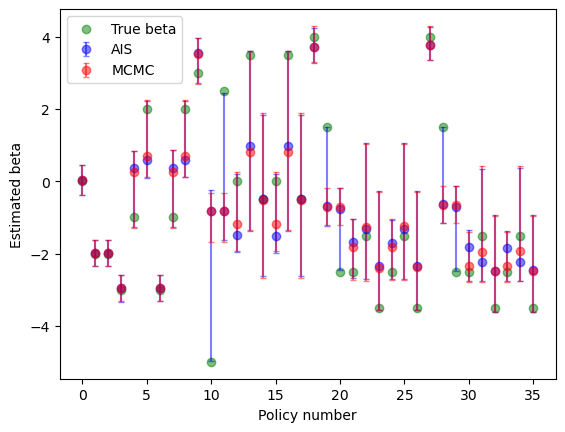

In [45]:
plt.figure()
plt.errorbar(range(36), summ["0.5"], yerr=[summ["0.5"]-summ["0.025"], summ["0.975"]-summ["0.5"]], fmt='o', capsize=2, color = 'blue', alpha = 0.5, label = 'AIS')
plt.errorbar(range(36), mcmc_summ["0.5"], yerr=[mcmc_summ["0.5"]-mcmc_summ["0.025"], mcmc_summ["0.975"]-mcmc_summ["0.5"]], fmt='o', capsize=2, color = 'red', alpha = 0.5, label = 'MCMC')
plt.scatter(range(36), true_mu, color = 'green', alpha = 0.5, label = 'True beta')

plt.xlabel("Policy number")
plt.ylabel("Estimated beta")

plt.legend()

In [74]:
log_alpha = [np.log(max(1e-300, score_s(A))) for A in anchors]
log_alpha = [score_s(A) for A in anchors]

RPS_summ = quantiles_for_all_policies(
    RPS_states,
    log_alpha,
    D, y,                     # D[:,0] = global policy id; y is (N,) or (N,1)
    M,
    all_policies,                 # global policies list (len P)
    prof_idx_of_policy,       # length-P array: global policy id -> profile k
    R,                    # per-arm levels (len M)
    lattice_edges=None,
    mu0=0.0, kappa0=1.0, alpha0=2.0, beta0=2.0,
    p=[0.025,0.5,0.975], 
    seed=None
)

[ 0.04162559 -1.98726075 -1.98726075 -2.95949301  0.48216036  0.48216036
 -2.95949301  0.48216036  0.48216036  3.66136186 -0.74382327 -0.74382327
 -1.66638233  1.50253409  1.50253409 -1.66638233  1.50253409  1.50253409
  3.66136186 -0.74382327 -0.74382327 -1.66638233 -2.48070236 -2.48070236
 -1.66638233 -2.48070236 -2.48070236  3.66136186 -0.74382327 -0.74382327
 -1.66638233 -2.48070236 -2.48070236 -1.66638233 -2.48070236 -2.48070236]
[ 0.04162559 -1.98726075 -1.98726075 -2.95949301  0.48216036  0.48216036
 -2.95949301  0.48216036  0.48216036  3.66136186 -0.74382327 -0.74382327
 -1.66638233 -1.15292775 -1.15292775 -1.66638233 -1.15292775 -1.15292775
  3.66136186 -0.74382327 -0.74382327 -1.66638233 -1.15292775 -1.15292775
 -1.66638233 -1.15292775 -1.15292775  3.66136186 -0.74382327 -0.74382327
 -1.66638233 -1.15292775 -1.15292775 -1.66638233 -1.15292775 -1.15292775]
[ 0.04162559 -1.98726075 -1.98726075 -2.95949301  0.48216036  0.48216036
 -2.95949301  0.48216036  0.48216036  3.66136186 

In [63]:
policy_means[:,0] / policy_means[:,1]

array([ 0.04170884, -1.97917303, -1.999323  , -2.98829513, -0.9984268 ,
        1.91972595, -2.93660988, -1.01895916,  2.02726578,  2.99746394,
       -5.00376792,  2.46318781, -0.00686039,  3.5160384 , -0.50066228,
       -0.01672186,  3.48737158, -0.48960628,  4.00611089,  1.53909057,
       -2.50438393, -2.44769837, -1.46646023, -3.52555926, -2.5498859 ,
       -1.42339631, -3.41785679,  3.98783346,  1.48901634, -2.44757016,
       -2.43131515, -1.55718091, -3.47826444, -2.5491451 , -1.50709853,
       -3.47476379])

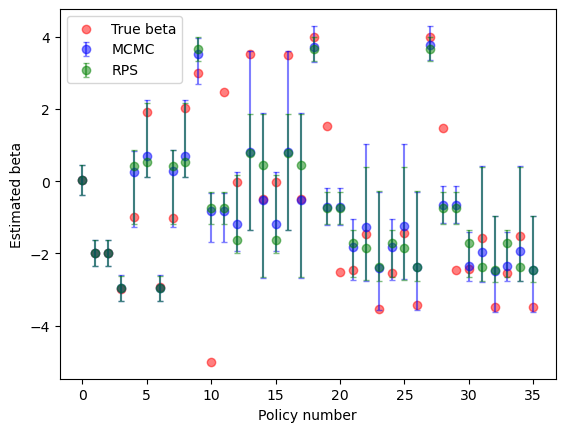

In [79]:
plt.figure()
plt.errorbar(range(36), mcmc_summ["0.5"], yerr=[mcmc_summ["0.5"]-mcmc_summ["0.025"], mcmc_summ["0.975"]-mcmc_summ["0.5"]], fmt='o', capsize=2, color = 'blue', alpha = 0.5, label = 'MCMC')
plt.errorbar(range(36), RPS_summ["0.5"], yerr=[RPS_summ["0.5"]-RPS_summ["0.025"], RPS_summ["0.975"]-RPS_summ["0.5"]], fmt='o', capsize=2, color = 'green', alpha = 0.5, label = 'RPS')
plt.scatter(range(36), policy_means[:,0]/policy_means[:,1], color = 'red', alpha = 0.5, label = 'True beta')

plt.xlabel("Policy number")
plt.ylabel("Estimated beta")

plt.legend()

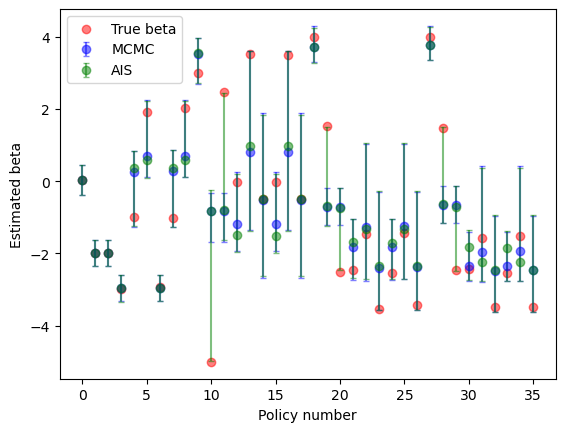

In [83]:
plt.figure()
plt.errorbar(range(36), mcmc_summ["0.5"], yerr=[mcmc_summ["0.5"]-mcmc_summ["0.025"], mcmc_summ["0.975"]-mcmc_summ["0.5"]], fmt='o', capsize=2, color = 'blue', alpha = 0.5, label = 'MCMC')
plt.errorbar(range(36), summ["0.5"], yerr=[summ["0.5"]-summ["0.025"], summ["0.975"]-summ["0.5"]], fmt='o', capsize=2, color = 'green', alpha = 0.5, label = 'AIS')

plt.scatter(range(36), policy_means[:,0]/policy_means[:,1], color = 'red', alpha = 0.5, label = 'True beta')

plt.xlabel("Policy number")
plt.ylabel("Estimated beta")

plt.legend()